In [13]:
def plot_graficos(ruta, ruta_corr, dir_wardar):
    import os
    import glob
    import re
    import numpy as np
    from astropy.io import fits
    from astropy.wcs import WCS
    import matplotlib.pyplot as plt
    import scipy.signal

    fits_orig = sorted(glob.glob(os.path.join(ruta, 'Gran*-star*_sum_*_fsr1.05_AIR_modificado.fits')))
    fits_corr = sorted(glob.glob(os.path.join(ruta_corr, '*.par_tac.fits')))
    os.makedirs(dir_wardar, exist_ok=True)

    for file_corr, file_orig in zip(fits_corr, fits_orig):
        # ------------------- Leer datos -------------------
        with fits.open(file_corr) as hd1:
            datos = hd1[1].data
            lam_corr = datos['LAMBDA'] * 1e4    # en Ångstroms
            flux_corr = datos['CFLUX']

        with fits.open(file_orig) as hd2:
            data = hd2[0].data
            hdr2 = hd2[0].header
            n_pix = data.shape[0]
            w = WCS(hdr2, naxis=1)
            lam_orig = w.pixel_to_world(np.arange(n_pix)).value
            flux_orig = data

        # Extraer número de orden
        match = re.search(r'_m(\d+)_', file_corr)
        orden = match.group(1) if match else "?"

        # Rango común de longitudes de onda
        min_lam = max(lam_corr.min(), lam_orig.min())
        max_lam = min(lam_corr.max(), lam_orig.max())

        # Dividir en 4 segmentos iguales
        edges = np.linspace(min_lam, max_lam, 5)   # 4 intervalos → 5 bordes

        # ------------------- Crear figura con 4 paneles -------------------
        fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=False)
        fig.suptitle(f"Orden m{orden} – Comparación corregido vs original (4 segmentos)", fontsize=16, y=0.98)

        shifts = []

        for i in range(4):
            start, end = edges[i], edges[i+1]

            # Máscaras para cada segmento
            mask_corr = (lam_corr >= start) & (lam_corr <= end)
            mask_orig = (lam_orig >= start) & (lam_orig <= end)

            if np.count_nonzero(mask_corr) < 2 or np.count_nonzero(mask_orig) < 2:
                axes[i].text(0.5, 0.5, "Sin datos suficientes en este rango", transform=axes[i].transAxes,
                             ha='center', va='center', color='red', fontsize=12)
                axes[i].set_title(f"Segmento {i+1}: [{start:.1f} – {end:.1f}] Å → Sin datos")
                continue

            # Crear grilla común fina
            common_grid = np.linspace(start, end, 1000)
            delta_lam = common_grid[1] - common_grid[0]

            # Interpolar flujos
            flux_corr_interp = np.interp(common_grid, lam_corr[mask_corr], flux_corr[mask_corr])
            flux_orig_interp = np.interp(common_grid, lam_orig[mask_orig], flux_orig[mask_orig])

            # Normalizar para mejor correlación (enfocada en la forma)
            def normalize(flux):
                mean = np.mean(flux)
                std = np.std(flux)
                if std == 0:
                    return flux - mean  # evitar división por cero
                return (flux - mean) / std

            flux_corr_norm = normalize(flux_corr_interp)
            flux_orig_norm = normalize(flux_orig_interp)

            # Correlación cruzada
            corr = scipy.signal.correlate(flux_corr_norm, flux_orig_norm, mode='full')
            lags = np.arange(-len(common_grid) + 1, len(common_grid))
            shift_pixels = lags[np.argmax(corr)]
            shift = shift_pixels * delta_lam
            shifts.append(shift)

            # Graficar los datos originales
            axes[i].plot(lam_corr[mask_corr], flux_corr[mask_corr], color='blue', lw=1.2, label='Corregido')
            axes[i].plot(lam_orig[mask_orig], flux_orig[mask_orig], color='orange', lw=1, alpha=0.8, label='Original')

            axes[i].set_xlim(start, end)
            axes[i].set_ylabel("Flujo")
            axes[i].legend(fontsize=9, loc='upper right')
            axes[i].grid(alpha=0.3)

            # Título con el corrimiento
            axes[i].set_title(f"Segmento {i+1} [{start:.1f}–{end:.1f} Å]  →  Δλ_shift = {shift:+.4f} Å",
                              fontsize=11, pad=8)

        # Etiqueta común de eje X solo en el último panel
        axes[3].set_xlabel("Longitud de onda [Å]")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # deja espacio para el suptitle

        # Guardar
        save_name = os.path.join(dir_wardar, f"orden_m{orden}_4segmentos.png")
        plt.savefig(save_name, dpi=200)
        plt.close()

        # Imprimir resumen en consola
        print(f"\nOrden m{orden} guardado: {save_name}")
        print("Corrimientos (shifts) por segmento (cantidad para alinear orig con corr):")
        for i, s in enumerate(shifts, 1):
            print(f"   Segmento {i}: {s:+.5f} Å")
        print("-" * 50)

In [14]:
direc = "/home/nacho/molecfit_test/mis_outputs_star1/"
direc_corr =  "/home/nacho/molecfit_test/mis_outputs_star1/"
wardar = "/home/nacho/molecfit_test/img_compare_star_1/"
plot_graficos(direc,direc_corr,wardar)


Orden m43 guardado: /home/nacho/molecfit_test/img_compare_star_1/orden_m43_4segmentos.png
Corrimientos (shifts) por segmento (cantidad para alinear orig con corr):
   Segmento 1: +3.51922 Å
   Segmento 2: +3.51922 Å
   Segmento 3: +3.59572 Å
   Segmento 4: +3.59572 Å
--------------------------------------------------

Orden m44 guardado: /home/nacho/molecfit_test/img_compare_star_1/orden_m44_4segmentos.png
Corrimientos (shifts) por segmento (cantidad para alinear orig con corr):
   Segmento 1: +3.41765 Å
   Segmento 2: +60.68228 Å
   Segmento 3: +3.49360 Å
   Segmento 4: +3.49360 Å
--------------------------------------------------

Orden m45 guardado: /home/nacho/molecfit_test/img_compare_star_1/orden_m45_4segmentos.png
Corrimientos (shifts) por segmento (cantidad para alinear orig con corr):
   Segmento 1: +3.35443 Å
   Segmento 2: +3.42580 Å
   Segmento 3: +3.42580 Å
   Segmento 4: +3.42580 Å
--------------------------------------------------

Orden m46 guardado: /home/nacho/molecf

In [17]:
direc = "/home/nacho/molecfit_test/mis_outputs_star3/"
direc_corr =  "/home/nacho/molecfit_test/mis_outputs_star3/"
wardar = "/home/nacho/molecfit_test/img_compare_star_3/"
plot_graficos(direc,direc_corr,wardar)

a string value was expected. [astropy.wcs.wcs]


Guardado: /home/nacho/molecfit_test/img_compare_star_3/orden_m43.png
Guardado: /home/nacho/molecfit_test/img_compare_star_3/orden_m44.png
Guardado: /home/nacho/molecfit_test/img_compare_star_3/orden_m45.png
Guardado: /home/nacho/molecfit_test/img_compare_star_3/orden_m46.png
Guardado: /home/nacho/molecfit_test/img_compare_star_3/orden_m47.png
Guardado: /home/nacho/molecfit_test/img_compare_star_3/orden_m48.png
Guardado: /home/nacho/molecfit_test/img_compare_star_3/orden_m51.png
Guardado: /home/nacho/molecfit_test/img_compare_star_3/orden_m52.png
Guardado: /home/nacho/molecfit_test/img_compare_star_3/orden_m53.png
Guardado: /home/nacho/molecfit_test/img_compare_star_3/orden_m54.png
Guardado: /home/nacho/molecfit_test/img_compare_star_3/orden_m55.png
Guardado: /home/nacho/molecfit_test/img_compare_star_3/orden_m56.png
Guardado: /home/nacho/molecfit_test/img_compare_star_3/orden_m57.png


In [18]:
direc = "/home/nacho/molecfit_test/mis_outputs_star4/"
direc_corr =  "/home/nacho/molecfit_test/mis_outputs_star4/"
wardar = "/home/nacho/molecfit_test/img_compare_star_4/"
plot_graficos(direc,direc_corr,wardar)

a string value was expected. [astropy.wcs.wcs]


Guardado: /home/nacho/molecfit_test/img_compare_star_4/orden_m43.png
Guardado: /home/nacho/molecfit_test/img_compare_star_4/orden_m44.png
Guardado: /home/nacho/molecfit_test/img_compare_star_4/orden_m45.png
Guardado: /home/nacho/molecfit_test/img_compare_star_4/orden_m46.png
Guardado: /home/nacho/molecfit_test/img_compare_star_4/orden_m47.png
Guardado: /home/nacho/molecfit_test/img_compare_star_4/orden_m48.png
Guardado: /home/nacho/molecfit_test/img_compare_star_4/orden_m51.png
Guardado: /home/nacho/molecfit_test/img_compare_star_4/orden_m52.png
Guardado: /home/nacho/molecfit_test/img_compare_star_4/orden_m53.png
Guardado: /home/nacho/molecfit_test/img_compare_star_4/orden_m54.png
Guardado: /home/nacho/molecfit_test/img_compare_star_4/orden_m55.png
Guardado: /home/nacho/molecfit_test/img_compare_star_4/orden_m56.png
Guardado: /home/nacho/molecfit_test/img_compare_star_4/orden_m57.png


In [19]:
direc = "/home/nacho/molecfit_test/mis_outputs_star7/"
direc_corr =  "/home/nacho/molecfit_test/mis_outputs_star7/"
wardar = "/home/nacho/molecfit_test/img_compare_star_7/"
plot_graficos(direc,direc_corr,wardar)

a string value was expected. [astropy.wcs.wcs]


Guardado: /home/nacho/molecfit_test/img_compare_star_7/orden_m43.png
Guardado: /home/nacho/molecfit_test/img_compare_star_7/orden_m44.png
Guardado: /home/nacho/molecfit_test/img_compare_star_7/orden_m45.png
Guardado: /home/nacho/molecfit_test/img_compare_star_7/orden_m46.png
Guardado: /home/nacho/molecfit_test/img_compare_star_7/orden_m47.png
Guardado: /home/nacho/molecfit_test/img_compare_star_7/orden_m48.png
Guardado: /home/nacho/molecfit_test/img_compare_star_7/orden_m51.png
Guardado: /home/nacho/molecfit_test/img_compare_star_7/orden_m52.png
Guardado: /home/nacho/molecfit_test/img_compare_star_7/orden_m53.png
Guardado: /home/nacho/molecfit_test/img_compare_star_7/orden_m54.png
Guardado: /home/nacho/molecfit_test/img_compare_star_7/orden_m55.png
Guardado: /home/nacho/molecfit_test/img_compare_star_7/orden_m56.png
Guardado: /home/nacho/molecfit_test/img_compare_star_7/orden_m57.png


In [20]:
direc = "/home/nacho/molecfit_test/mis_outputs_star1/"
direc_corr =  "/home/nacho/molecfit_test/mis_outputs_star1/"
wardar = "/home/nacho/molecfit_test/img_compare_star_1/"
plot_graficos(direc,direc_corr,wardar)

Guardado: /home/nacho/molecfit_test/img_compare_star_1/orden_m43.png
Guardado: /home/nacho/molecfit_test/img_compare_star_1/orden_m44.png
Guardado: /home/nacho/molecfit_test/img_compare_star_1/orden_m45.png
Guardado: /home/nacho/molecfit_test/img_compare_star_1/orden_m46.png
Guardado: /home/nacho/molecfit_test/img_compare_star_1/orden_m47.png
Guardado: /home/nacho/molecfit_test/img_compare_star_1/orden_m48.png
Guardado: /home/nacho/molecfit_test/img_compare_star_1/orden_m51.png
Guardado: /home/nacho/molecfit_test/img_compare_star_1/orden_m52.png
Guardado: /home/nacho/molecfit_test/img_compare_star_1/orden_m53.png
Guardado: /home/nacho/molecfit_test/img_compare_star_1/orden_m54.png
Guardado: /home/nacho/molecfit_test/img_compare_star_1/orden_m55.png
Guardado: /home/nacho/molecfit_test/img_compare_star_1/orden_m56.png
Guardado: /home/nacho/molecfit_test/img_compare_star_1/orden_m57.png


In [21]:
direc = "/home/nacho/molecfit_test/mis_outputs_star8/"
direc_corr =  "/home/nacho/molecfit_test/mis_outputs_star8/"
wardar = "/home/nacho/molecfit_test/img_compare_star_8/"
plot_graficos(direc,direc_corr,wardar)

a string value was expected. [astropy.wcs.wcs]


Guardado: /home/nacho/molecfit_test/img_compare_star_8/orden_m43.png
Guardado: /home/nacho/molecfit_test/img_compare_star_8/orden_m44.png
Guardado: /home/nacho/molecfit_test/img_compare_star_8/orden_m45.png
Guardado: /home/nacho/molecfit_test/img_compare_star_8/orden_m46.png
Guardado: /home/nacho/molecfit_test/img_compare_star_8/orden_m47.png
Guardado: /home/nacho/molecfit_test/img_compare_star_8/orden_m48.png
Guardado: /home/nacho/molecfit_test/img_compare_star_8/orden_m51.png
Guardado: /home/nacho/molecfit_test/img_compare_star_8/orden_m52.png
Guardado: /home/nacho/molecfit_test/img_compare_star_8/orden_m53.png
Guardado: /home/nacho/molecfit_test/img_compare_star_8/orden_m54.png
Guardado: /home/nacho/molecfit_test/img_compare_star_8/orden_m55.png
Guardado: /home/nacho/molecfit_test/img_compare_star_8/orden_m56.png
Guardado: /home/nacho/molecfit_test/img_compare_star_8/orden_m57.png


In [22]:
direc = "/home/nacho/molecfit_test/mis_outputs_star9/"
direc_corr =  "/home/nacho/molecfit_test/mis_outputs_star9/"
wardar = "/home/nacho/molecfit_test/img_compare_star_9/"
plot_graficos(direc,direc_corr,wardar)

a string value was expected. [astropy.wcs.wcs]


Guardado: /home/nacho/molecfit_test/img_compare_star_9/orden_m43.png
Guardado: /home/nacho/molecfit_test/img_compare_star_9/orden_m44.png
Guardado: /home/nacho/molecfit_test/img_compare_star_9/orden_m45.png
Guardado: /home/nacho/molecfit_test/img_compare_star_9/orden_m46.png
Guardado: /home/nacho/molecfit_test/img_compare_star_9/orden_m47.png
Guardado: /home/nacho/molecfit_test/img_compare_star_9/orden_m48.png
Guardado: /home/nacho/molecfit_test/img_compare_star_9/orden_m51.png
Guardado: /home/nacho/molecfit_test/img_compare_star_9/orden_m52.png
Guardado: /home/nacho/molecfit_test/img_compare_star_9/orden_m53.png
Guardado: /home/nacho/molecfit_test/img_compare_star_9/orden_m54.png
Guardado: /home/nacho/molecfit_test/img_compare_star_9/orden_m55.png
Guardado: /home/nacho/molecfit_test/img_compare_star_9/orden_m56.png
Guardado: /home/nacho/molecfit_test/img_compare_star_9/orden_m57.png



Procesando estrella: ordenes_star1
Encontrados 13 órdenes espectrales
  Procesando orden 1/13: Gran01-star3_sum_m43_fsr1.05_AIR.fits
    → 42 líneas ajustadas
  Procesando orden 2/13: Gran01-star3_sum_m44_fsr1.05_AIR.fits
    → 53 líneas ajustadas
  Procesando orden 3/13: Gran01-star3_sum_m45_fsr1.05_AIR.fits
    → 21 líneas ajustadas
  Procesando orden 4/13: Gran01-star3_sum_m46_fsr1.05_AIR.fits
    → 20 líneas ajustadas
  Procesando orden 5/13: Gran01-star3_sum_m47_fsr1.05_AIR.fits
    → 41 líneas ajustadas
  Procesando orden 6/13: Gran01-star3_sum_m48_fsr1.05_AIR.fits
    → 48 líneas ajustadas
  Procesando orden 7/13: Gran01-star3_sum_m51_fsr1.05_AIR.fits
    → 59 líneas ajustadas
  Procesando orden 8/13: Gran01-star3_sum_m52_fsr1.05_AIR.fits
    → 32 líneas ajustadas
  Procesando orden 9/13: Gran01-star3_sum_m53_fsr1.05_AIR.fits
    → 15 líneas ajustadas
  Procesando orden 10/13: Gran01-star3_sum_m54_fsr1.05_AIR.fits
    → 20 líneas ajustadas
  Procesando orden 11/13: Gran01-star3

/tmp/ipykernel_47270/4190554386.py:51: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(gaussiana, x_data, y_data, p0=[A_guess, mu_guess, sigma_guess])


  Gráfica guardada en: /home/nacho/molecfit_test/espectros2/ordenes_star1/ordenes_star1_resolucion_espectral.png


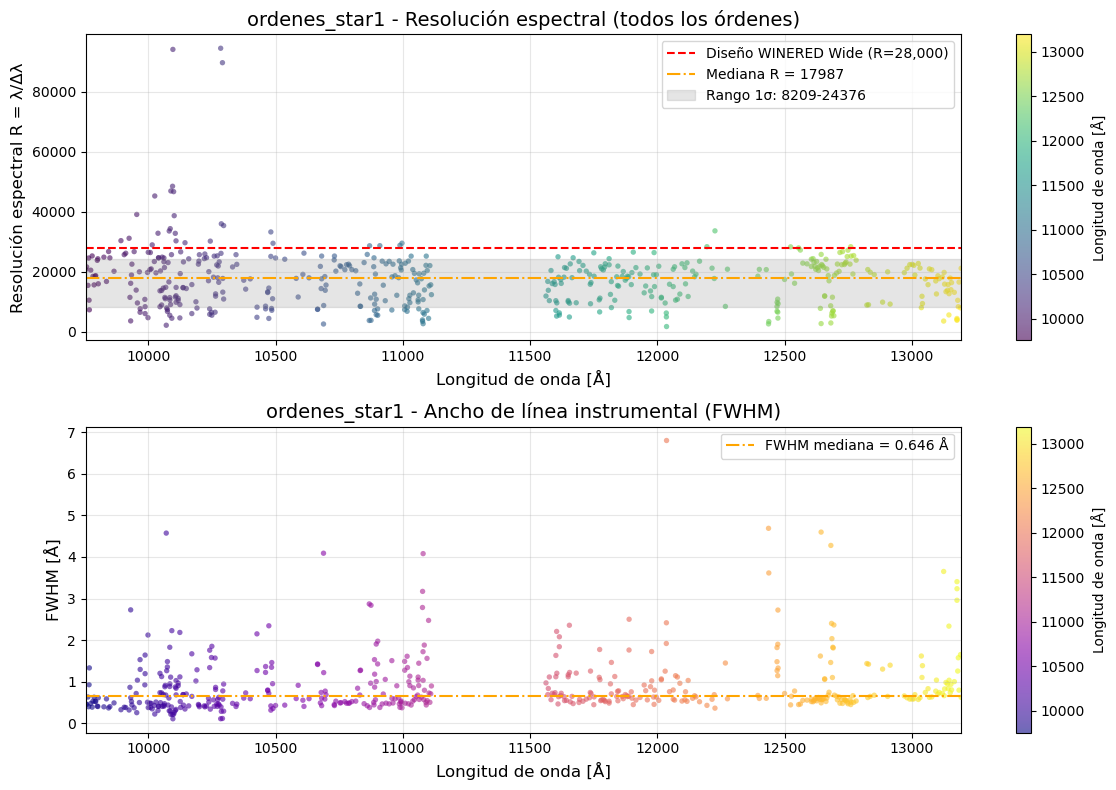


--- Estadísticas para ordenes_star1 ---
  Total líneas ajustadas: 488
  Rango de longitudes de onda: 9754 - 13193 Å
  R promedio: 17501 ± 9822
  R mediana: 17987
  R percentil 16: 8209
  R percentil 84: 24376
  FWHM promedio: 0.9160 ± 0.7392 Å
  FWHM mediana: 0.6460 Å
  ⚠ Resolución baja. Verificar si se usó una rendija más ancha

Procesando estrella: ordenes_star3
Encontrados 13 órdenes espectrales
  Procesando orden 1/13: Gran01-star3_sum_m43_fsr1.05_AIR.fits
    → 38 líneas ajustadas
  Procesando orden 2/13: Gran01-star3_sum_m44_fsr1.05_AIR.fits
    → 53 líneas ajustadas
  Procesando orden 3/13: Gran01-star3_sum_m45_fsr1.05_AIR.fits
    → 18 líneas ajustadas
  Procesando orden 4/13: Gran01-star3_sum_m46_fsr1.05_AIR.fits
    → 21 líneas ajustadas
  Procesando orden 5/13: Gran01-star3_sum_m47_fsr1.05_AIR.fits
    → 39 líneas ajustadas
  Procesando orden 6/13: Gran01-star3_sum_m48_fsr1.05_AIR.fits
    → 49 líneas ajustadas
  Procesando orden 7/13: Gran01-star3_sum_m51_fsr1.05_AIR.fits

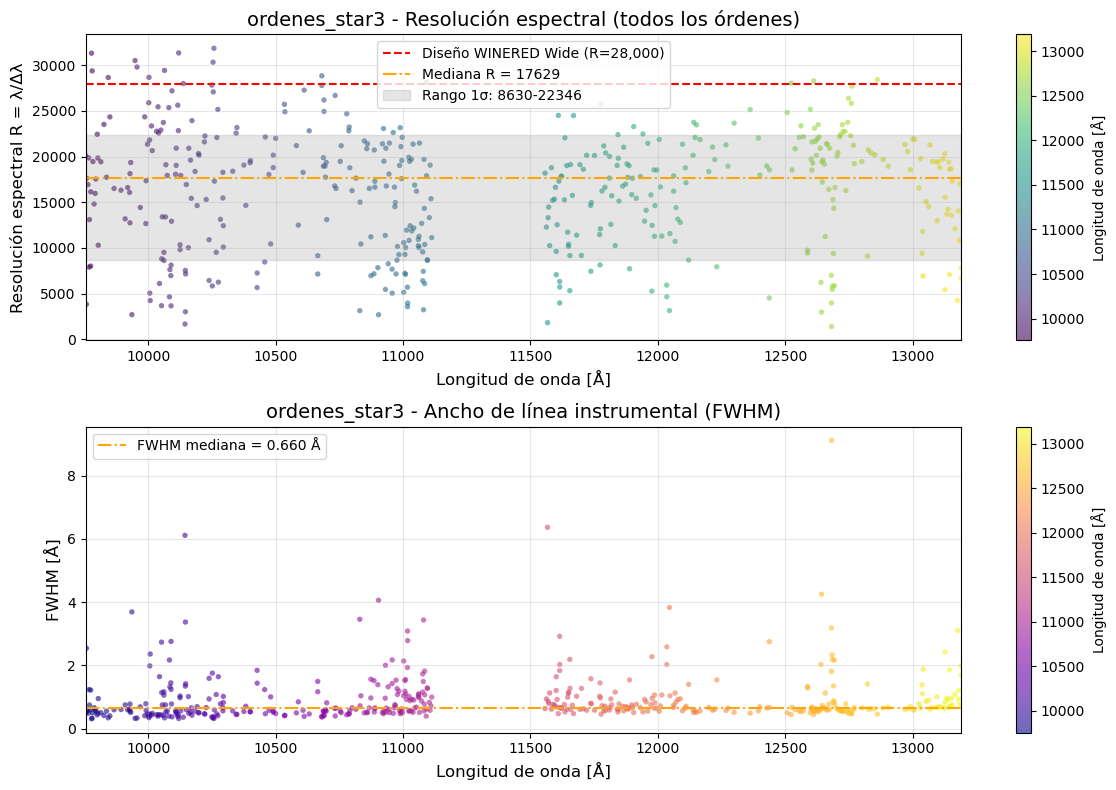


--- Estadísticas para ordenes_star3 ---
  Total líneas ajustadas: 460
  Rango de longitudes de onda: 9754 - 13191 Å
  R promedio: 16308 ± 6585
  R mediana: 17629
  R percentil 16: 8630
  R percentil 84: 22346
  FWHM promedio: 0.9371 ± 0.8079 Å
  FWHM mediana: 0.6596 Å
  ⚠ Resolución baja. Verificar si se usó una rendija más ancha

Procesando estrella: ordenes_star4
Encontrados 13 órdenes espectrales
  Procesando orden 1/13: Gran1-star4_sum_m43_fsr1.05_AIR.fits
    → 40 líneas ajustadas
  Procesando orden 2/13: Gran1-star4_sum_m44_fsr1.05_AIR.fits
    → 56 líneas ajustadas
  Procesando orden 3/13: Gran1-star4_sum_m45_fsr1.05_AIR.fits
    → 20 líneas ajustadas
  Procesando orden 4/13: Gran1-star4_sum_m46_fsr1.05_AIR.fits
    → 30 líneas ajustadas
  Procesando orden 5/13: Gran1-star4_sum_m47_fsr1.05_AIR.fits
    → 38 líneas ajustadas
  Procesando orden 6/13: Gran1-star4_sum_m48_fsr1.05_AIR.fits
    → 39 líneas ajustadas
  Procesando orden 7/13: Gran1-star4_sum_m51_fsr1.05_AIR.fits
    → 

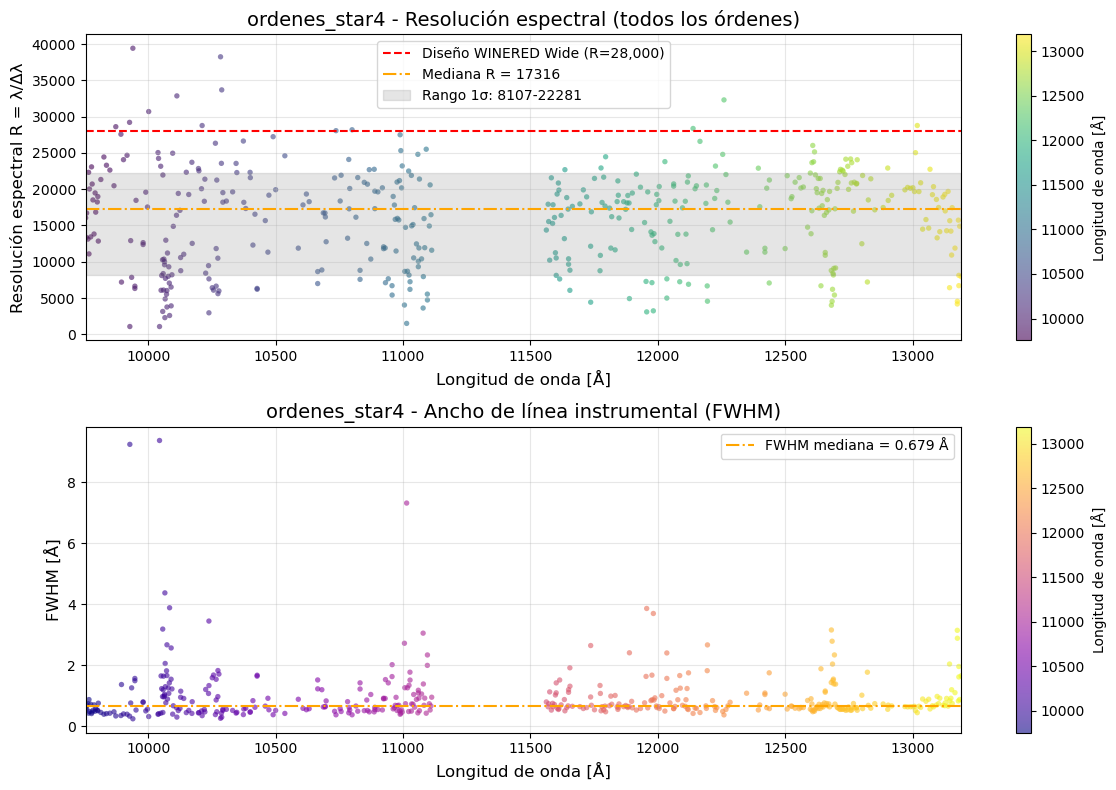


--- Estadísticas para ordenes_star4 ---
  Total líneas ajustadas: 433
  Rango de longitudes de onda: 9754 - 13190 Å
  R promedio: 16039 ± 6691
  R mediana: 17316
  R percentil 16: 8107
  R percentil 84: 22281
  FWHM promedio: 0.9671 ± 0.8877 Å
  FWHM mediana: 0.6787 Å
  ⚠ Resolución baja. Verificar si se usó una rendija más ancha

Procesando estrella: ordenes_star7
Encontrados 13 órdenes espectrales
  Procesando orden 1/13: Gran1-star7_sum_m43_fsr1.05_AIR.fits
    → 33 líneas ajustadas
  Procesando orden 2/13: Gran1-star7_sum_m44_fsr1.05_AIR.fits
    → 45 líneas ajustadas
  Procesando orden 3/13: Gran1-star7_sum_m45_fsr1.05_AIR.fits
    → 18 líneas ajustadas
  Procesando orden 4/13: Gran1-star7_sum_m46_fsr1.05_AIR.fits
    → 15 líneas ajustadas
  Procesando orden 5/13: Gran1-star7_sum_m47_fsr1.05_AIR.fits
    → 27 líneas ajustadas
  Procesando orden 6/13: Gran1-star7_sum_m48_fsr1.05_AIR.fits
    → 36 líneas ajustadas
  Procesando orden 7/13: Gran1-star7_sum_m51_fsr1.05_AIR.fits
    → 

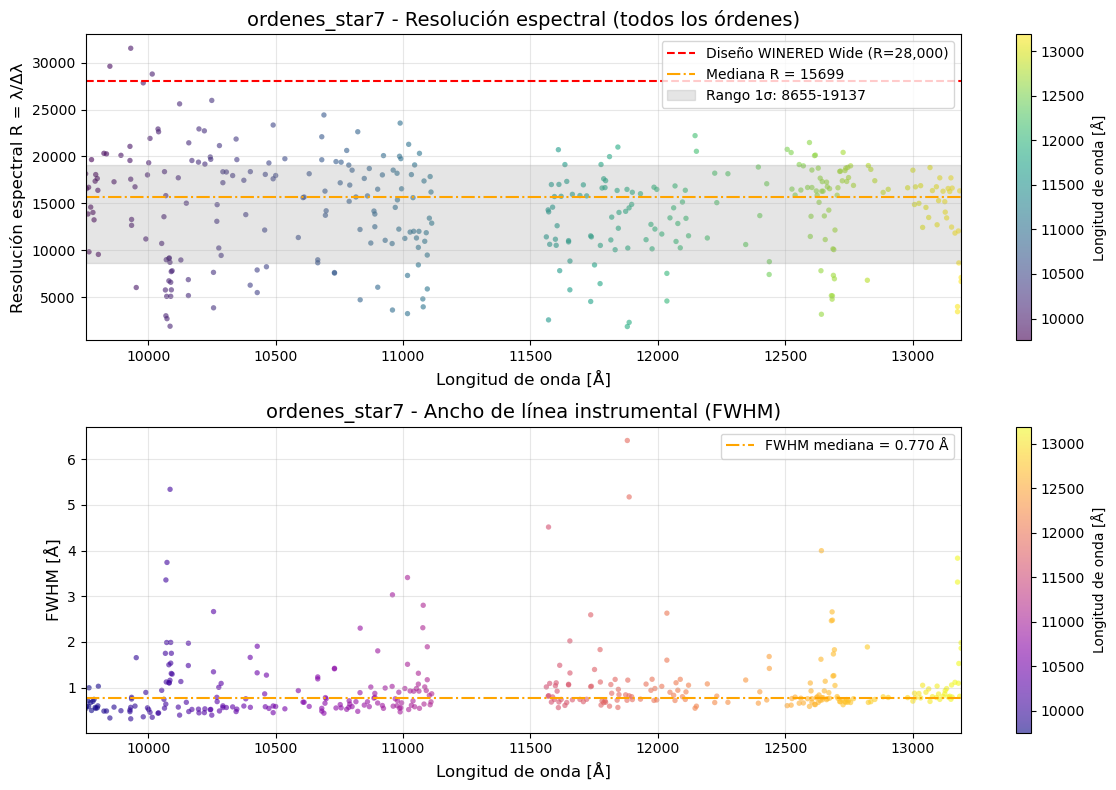


--- Estadísticas para ordenes_star7 ---
  Total líneas ajustadas: 344
  Rango de longitudes de onda: 9754 - 13190 Å
  R promedio: 14458 ± 5285
  R mediana: 15699
  R percentil 16: 8655
  R percentil 84: 19137
  FWHM promedio: 1.0032 ± 0.7447 Å
  FWHM mediana: 0.7699 Å
  ⚠ Resolución baja. Verificar si se usó una rendija más ancha

Procesando estrella: ordenes_star8
Encontrados 13 órdenes espectrales
  Procesando orden 1/13: Gran01-star8_sum_m43_fsr1.05_AIR.fits
    → 42 líneas ajustadas
  Procesando orden 2/13: Gran01-star8_sum_m44_fsr1.05_AIR.fits
    → 50 líneas ajustadas
  Procesando orden 3/13: Gran01-star8_sum_m45_fsr1.05_AIR.fits
    → 17 líneas ajustadas
  Procesando orden 4/13: Gran01-star8_sum_m46_fsr1.05_AIR.fits
    → 18 líneas ajustadas
  Procesando orden 5/13: Gran01-star8_sum_m47_fsr1.05_AIR.fits
    → 40 líneas ajustadas
  Procesando orden 6/13: Gran01-star8_sum_m48_fsr1.05_AIR.fits
    → 49 líneas ajustadas
  Procesando orden 7/13: Gran01-star8_sum_m51_fsr1.05_AIR.fits

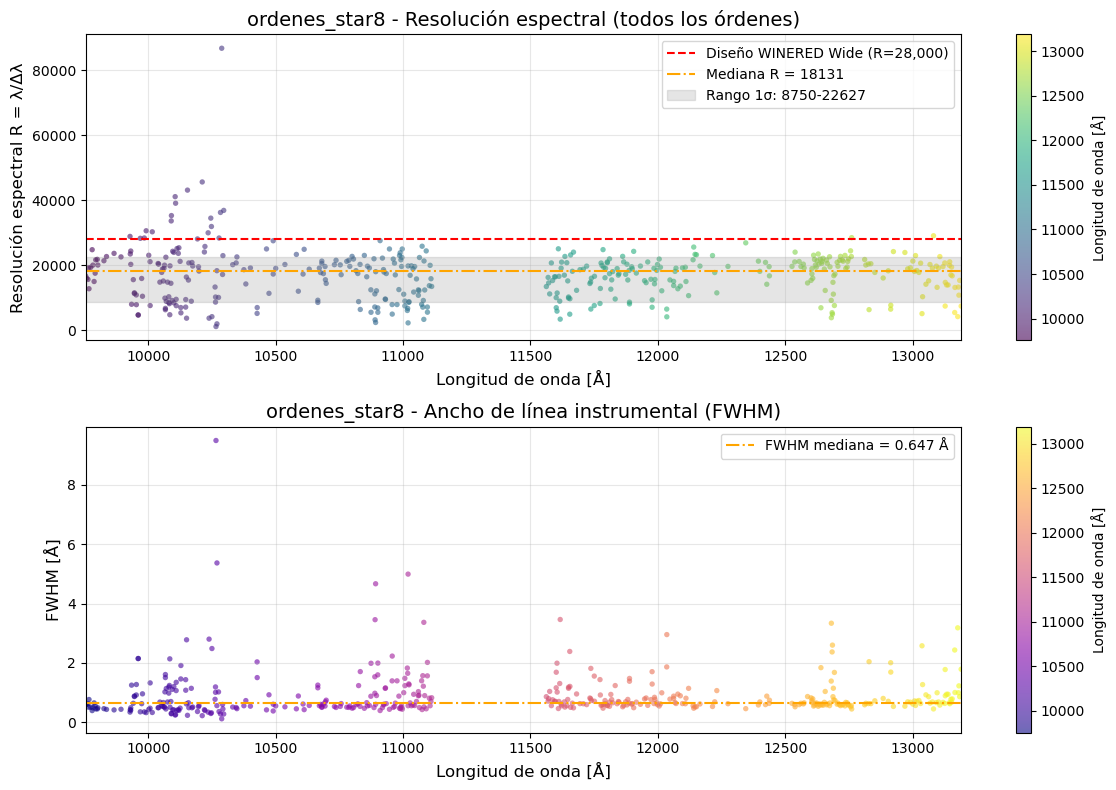


--- Estadísticas para ordenes_star8 ---
  Total líneas ajustadas: 436
  Rango de longitudes de onda: 9754 - 13191 Å
  R promedio: 17042 ± 7730
  R mediana: 18131
  R percentil 16: 8750
  R percentil 84: 22627
  FWHM promedio: 0.8952 ± 0.7601 Å
  FWHM mediana: 0.6471 Å
  ⚠ Resolución baja. Verificar si se usó una rendija más ancha

Procesando estrella: ordenes_star9
Encontrados 13 órdenes espectrales
  Procesando orden 1/13: Gran1-star9_sum_m43_fsr1.05_AIR.fits
    → 41 líneas ajustadas
  Procesando orden 2/13: Gran1-star9_sum_m44_fsr1.05_AIR.fits
    → 49 líneas ajustadas
  Procesando orden 3/13: Gran1-star9_sum_m45_fsr1.05_AIR.fits
    → 16 líneas ajustadas
  Procesando orden 4/13: Gran1-star9_sum_m46_fsr1.05_AIR.fits
    → 22 líneas ajustadas
  Procesando orden 5/13: Gran1-star9_sum_m47_fsr1.05_AIR.fits
    → 31 líneas ajustadas
  Procesando orden 6/13: Gran1-star9_sum_m48_fsr1.05_AIR.fits
    → 38 líneas ajustadas
  Procesando orden 7/13: Gran1-star9_sum_m51_fsr1.05_AIR.fits
    → 

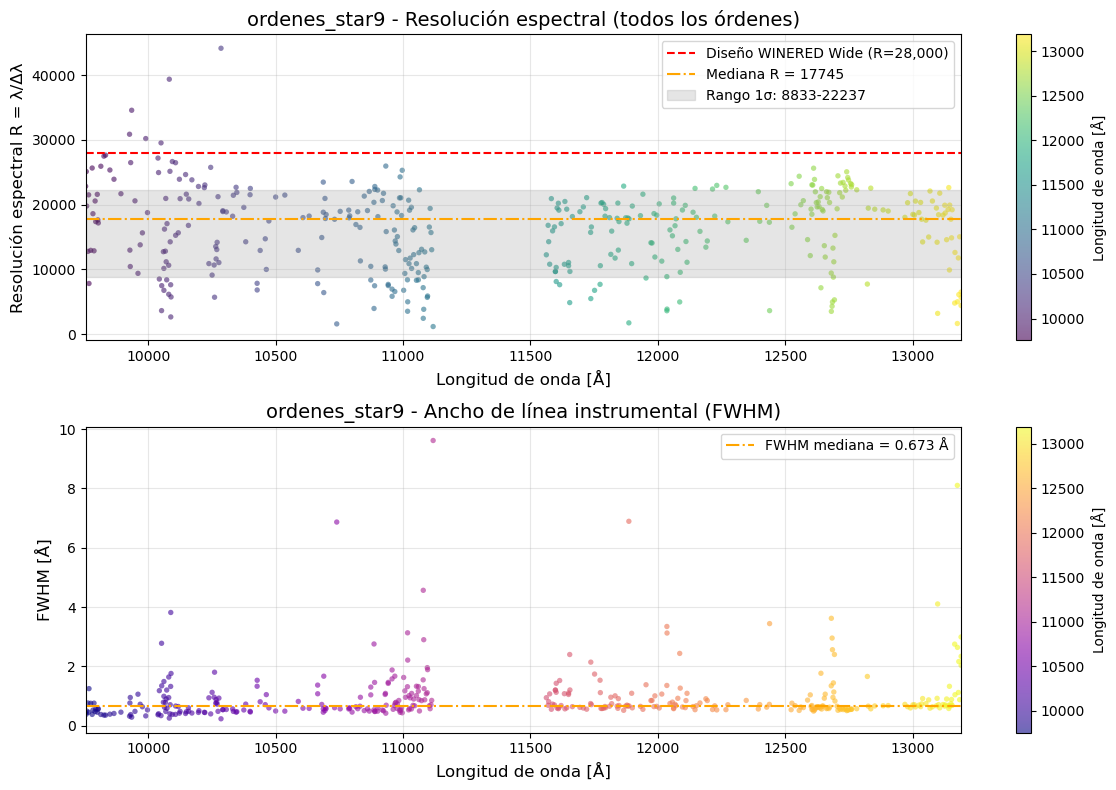


--- Estadísticas para ordenes_star9 ---
  Total líneas ajustadas: 392
  Rango de longitudes de onda: 9754 - 13191 Å
  R promedio: 16211 ± 6537
  R mediana: 17745
  R percentil 16: 8833
  R percentil 84: 22237
  FWHM promedio: 0.9666 ± 0.9434 Å
  FWHM mediana: 0.6729 Å
  ⚠ Resolución baja. Verificar si se usó una rendija más ancha

Procesamiento completado para todas las estrellas


In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# Definir la función gaussiana
def gaussiana(x, A, mu, sigma):
    return A * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

def analizar_espectro(archivo):
    """Analiza un archivo FITS y devuelve listas de longitudes de onda, R y FWHM"""
    with fits.open(archivo) as hdul:
        data = hdul[0].data
        flux = data
        invert_flux = 1 - flux
        hdr = hdul[0].header
        n_pix = data.shape[0]
        
        # Obtener la calibración de longitudes de onda
        w = WCS(hdr, naxis=1)
        lam = w.pixel_to_world(np.arange(n_pix)).value
        
        # Encontrar picos
        picos = find_peaks(invert_flux, height=np.max(invert_flux) * 0.2)[0]
        
        longitudes = []
        resoluciones = []
        fwhms = []
        
        for pico in picos:
            ventana = 5
            inicio = max(0, pico - ventana)
            fin = min(n_pix, pico + ventana + 1)
            
            x_data = lam[inicio:fin]
            y_data = invert_flux[inicio:fin]
            
            # Estimaciones iniciales
            A_guess = np.max(y_data)
            mu_guess = lam[pico]
            if pico + 1 < n_pix:
                sigma_guess = abs(lam[pico+1] - lam[pico]) * 2
            else:
                sigma_guess = 0.1
            
            try:
                popt, _ = curve_fit(gaussiana, x_data, y_data, p0=[A_guess, mu_guess, sigma_guess])
                mu_fit, sigma_fit = popt[1], popt[2]
                
                fwhm_fit = 2 * np.sqrt(2 * np.log(2)) * sigma_fit
                R_fit = mu_fit / fwhm_fit
                
                # Solo guardar valores razonables
                if 1000 < R_fit < 100000 and fwhm_fit > 0:
                    longitudes.append(mu_fit)
                    fwhms.append(fwhm_fit)
                    resoluciones.append(R_fit)
                    
            except (RuntimeError, TypeError):
                continue
        
        return longitudes, resoluciones, fwhms

# Directorio principal
carpetas = "/home/nacho/molecfit_test/espectros2/"
contenido = [d for d in os.listdir(carpetas) 
             if os.path.isdir(os.path.join(carpetas, d))]

# Procesar cada estrella (subdirectorio)
for estrella in contenido:
    print(f"\n{'='*60}")
    print(f"Procesando estrella: {estrella}")
    print(f"{'='*60}")
    
    # Buscar todos los archivos FITS de esta estrella (todos los órdenes)
    archivos = glob.glob(os.path.join(carpetas, estrella, '*AIR.fits'))
    archivos.sort()
    
    print(f"Encontrados {len(archivos)} órdenes espectrales")
    
    # Acumular datos de todos los órdenes
    todas_longitudes = []
    todas_resoluciones = []
    todos_fwhms = []
    
    for idx, archivo in enumerate(archivos, 1):
        print(f"  Procesando orden {idx}/{len(archivos)}: {os.path.basename(archivo)}")
        
        longitudes, resoluciones, fwhms = analizar_espectro(archivo)
        
        todas_longitudes.extend(longitudes)
        todas_resoluciones.extend(resoluciones)
        todos_fwhms.extend(fwhms)
        
        print(f"    → {len(longitudes)} líneas ajustadas")
    
    # Convertir a arrays numpy
    todas_longitudes = np.array(todas_longitudes)
    todas_resoluciones = np.array(todas_resoluciones)
    todos_fwhms = np.array(todos_fwhms)
    
    if len(todas_resoluciones) > 0:
        # Crear figura con dos subplots
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))
        
        # Subplot 1: Resolución espectral (R) vs Longitud de onda
        ax1 = axes[0]
        scatter1 = ax1.scatter(todas_longitudes, todas_resoluciones, 
                              c=todas_longitudes, cmap='viridis', 
                              s=15, alpha=0.6, edgecolors='none')
        ax1.set_xlabel('Longitud de onda [Å]', fontsize=12)
        ax1.set_ylabel('Resolución espectral R = λ/Δλ', fontsize=12)
        ax1.set_title(f'{estrella} - Resolución espectral (todos los órdenes)', fontsize=14)
        ax1.axhline(y=28000, color='r', linestyle='--', linewidth=1.5, 
                   label='Diseño WINERED Wide (R=28,000)')
        ax1.axhline(y=np.median(todas_resoluciones), color='orange', 
                   linestyle='-.', linewidth=1.5, 
                   label=f'Mediana R = {np.median(todas_resoluciones):.0f}')
        ax1.fill_between([min(todas_longitudes), max(todas_longitudes)], 
                         [np.percentile(todas_resoluciones, 16)]*2,
                         [np.percentile(todas_resoluciones, 84)]*2,
                         alpha=0.2, color='gray', 
                         label=f'Rango 1σ: {np.percentile(todas_resoluciones, 16):.0f}-{np.percentile(todas_resoluciones, 84):.0f}')
        ax1.legend(loc='best', fontsize=10)
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim(min(todas_longitudes), max(todas_longitudes))
        
        # Añadir barra de color
        cbar = plt.colorbar(scatter1, ax=ax1)
        cbar.set_label('Longitud de onda [Å]')
        
        # Subplot 2: FWHM vs Longitud de onda
        ax2 = axes[1]
        scatter2 = ax2.scatter(todas_longitudes, todos_fwhms, 
                              c=todas_longitudes, cmap='plasma', 
                              s=15, alpha=0.6, edgecolors='none')
        ax2.set_xlabel('Longitud de onda [Å]', fontsize=12)
        ax2.set_ylabel('FWHM [Å]', fontsize=12)
        ax2.set_title(f'{estrella} - Ancho de línea instrumental (FWHM)', fontsize=14)
        ax2.axhline(y=np.median(todos_fwhms), color='orange', 
                   linestyle='-.', linewidth=1.5,
                   label=f'FWHM mediana = {np.median(todos_fwhms):.3f} Å')
        ax2.legend(loc='best', fontsize=10)
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim(min(todas_longitudes), max(todas_longitudes))
        
        cbar2 = plt.colorbar(scatter2, ax=ax2)
        cbar2.set_label('Longitud de onda [Å]')
        
        plt.tight_layout()
        
        # Guardar la figura
        output_path = os.path.join(carpetas, estrella, f'{estrella}_resolucion_espectral.png')
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"  Gráfica guardada en: {output_path}")
        
        plt.show()
        
        # Estadísticas resumidas
        print(f"\n--- Estadísticas para {estrella} ---")
        print(f"  Total líneas ajustadas: {len(todas_resoluciones)}")
        print(f"  Rango de longitudes de onda: {min(todas_longitudes):.0f} - {max(todas_longitudes):.0f} Å")
        print(f"  R promedio: {np.mean(todas_resoluciones):.0f} ± {np.std(todas_resoluciones):.0f}")
        print(f"  R mediana: {np.median(todas_resoluciones):.0f}")
        print(f"  R percentil 16: {np.percentile(todas_resoluciones, 16):.0f}")
        print(f"  R percentil 84: {np.percentile(todas_resoluciones, 84):.0f}")
        print(f"  FWHM promedio: {np.mean(todos_fwhms):.4f} ± {np.std(todos_fwhms):.4f} Å")
        print(f"  FWHM mediana: {np.median(todos_fwhms):.4f} Å")
        
        # Comparación con el paper
        if np.median(todas_resoluciones) > 25000:
            print(f"  ✓ Excelente! La resolución es comparable al Wide mode de WINERED")
        elif np.median(todas_resoluciones) > 20000:
            print(f"  ✓ Buena resolución, ligeramente por debajo del diseño")
        else:
            print(f"  ⚠ Resolución baja. Verificar si se usó una rendija más ancha")
            
    else:
        print(f"  ⚠ No se pudo ajustar ninguna línea para {estrella}")

print("\n" + "="*60)
print("Procesamiento completado para todas las estrellas")
print("="*60)

In [12]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import re

paths = ["/home/nacho/molecfit_test/mis_outputs_star1",
         "/home/nacho/molecfit_test/mis_outputs_star3",
         "/home/nacho/molecfit_test/mis_outputs_star4",
         "/home/nacho/molecfit_test/mis_outputs_star7",
         "/home/nacho/molecfit_test/mis_outputs_star8",
         "/home/nacho/molecfit_test/mis_outputs_star9",]

def extraer_craval_cdelt(archivo):
    with fits.open(archivo) as hdul:
        hdr = hdul[0].header
        crval1 = hdr.get('CRVAL1', None)
        cdelt1 = hdr.get('CDELT1', None)
        return crval1, cdelt1

# "Gran01-star3_sum_m43_fsr1.05_AIR_modificado.par_fit.res" 
# crear diccionarios con valores de fwhm para cada orden de cada estrella

dic = {}
for p in paths:
    archivos = glob.glob(os.path.join(p, '*modificado.par_fit.res'))
    nombre_estrella = os.path.basename(p)
    
    for archivo in archivos:
        # Extraer orden echelle del nombre del ARCHIVO
        magnitud_echelle = re.findall(r'm(\d+)', os.path.basename(archivo))
        orden = int(magnitud_echelle[0]) if magnitud_echelle else None
        
        with open(archivo, 'r') as f:
            encontrado = False
            for linea in f:
                if "FWHM of Gaussian in pixels:" in linea:
                    fwhm_pix = float(linea.split()[5])
                    if nombre_estrella not in dic:
                        dic[nombre_estrella] = {"fwhm": [], "orden": []}
                    dic[nombre_estrella]["fwhm"].append(fwhm_pix)
                    dic[nombre_estrella]["orden"].append(orden)
                    encontrado = True
                    break
            if not encontrado:
                print(f"Archivo: {os.path.basename(archivo)} → No se encontró FWHM")

dic_2 = {}
for p in paths:
    archivos = glob.glob(os.path.join(p, '*modificado.fits'))
    nombre_estrella = os.path.basename(p)
    for archivo in archivos:
        craval1, cdelt1 = extraer_craval_cdelt(archivo)
        if craval1 is not None and cdelt1 is not None:
            
            if str(os.path.basename(nombre_estrella)) not in dic_2:
                dic_2[str(os.path.basename(nombre_estrella))] = []
            dic_2[str(os.path.basename(nombre_estrella))].append((craval1, cdelt1))
        else: 
            print(f"Archivo: {os.path.basename(archivo)} → No se encontraron CRVAL1 o CDELT1")

dic


{'mis_outputs_star1': {'fwhm': [1.434,
   1.442,
   1.528,
   1.947,
   1.673,
   1.368,
   1.382,
   1.067,
   0.157,
   0.0,
   0.0,
   0.0,
   1.7],
  'orden': [43, 44, 45, 46, 47, 48, 51, 52, 53, 54, 55, 56, 57]},
 'mis_outputs_star3': {'fwhm': [1.46,
   1.571,
   1.943,
   1.861,
   1.748,
   1.5,
   1.277,
   1.345,
   0.0,
   0.0,
   0.0,
   0.652,
   1.953],
  'orden': [43, 44, 45, 46, 47, 48, 51, 52, 53, 54, 55, 56, 57]},
 'mis_outputs_star4': {'fwhm': [1.635,
   1.744,
   2.076,
   2.375,
   1.838,
   1.521,
   1.841,
   1.09,
   0.0,
   0.0,
   0.0,
   0.812,
   1.954],
  'orden': [43, 44, 45, 46, 47, 48, 51, 52, 53, 54, 55, 56, 57]},
 'mis_outputs_star7': {'fwhm': [2.48,
   2.35,
   2.044,
   2.974,
   2.763,
   2.074,
   2.202,
   1.988,
   0.0,
   0.0,
   0.0,
   1.249,
   2.16],
  'orden': [43, 44, 45, 46, 47, 48, 51, 52, 53, 54, 55, 56, 57]},
 'mis_outputs_star8': {'fwhm': [1.522,
   1.712,
   1.954,
   1.843,
   1.682,
   1.428,
   1.693,
   1.603,
   0.0,
   0.0,
   0

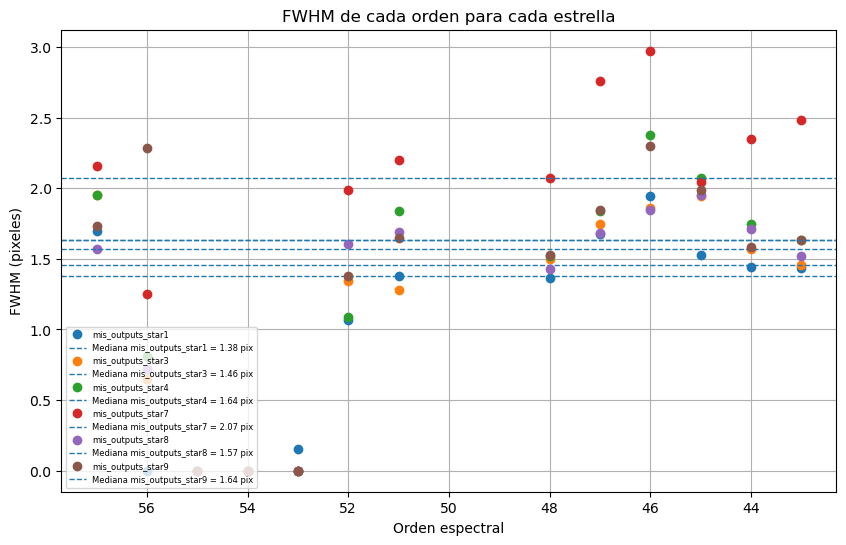

,mis_outputs_star1,mis_outputs_star3,mis_outputs_star4,mis_outputs_star7,mis_outputs_star8,mis_outputs_star9
orden_echelle,,,,,,
43,1.434,1.460,1.635,2.480,1.522,1.636
44,1.442,1.571,1.744,2.350,1.712,1.581
45,1.528,1.943,2.076,2.044,1.954,1.986
46,1.947,1.861,2.375,2.974,1.843,2.302
47,1.673,1.748,1.838,2.763,1.682,1.843
48,1.368,1.500,1.521,2.074,1.428,1.524
51,1.382,1.277,1.841,2.202,1.693,1.651
52,1.067,1.345,1.090,1.988,1.603,1.377
53,0.157,0.000,0.000,0.000,0.000,0.000


In [18]:
import pandas as pd 
dfs = []
for estrella, valores in dic.items():
    df_temp = pd.DataFrame({
        "orden": valores["orden"],
        estrella: valores["fwhm"]
    })
    dfs.append(df_temp.set_index("orden"))

df_fwhm = pd.concat(dfs, axis=1)
df_fwhm.index.name = "orden_echelle"
df_calib = pd.DataFrame.from_dict(dic_2, orient='index').transpose()
# graficar los fwhm para cada estrella
plt.figure(figsize=(10, 6))
for estrella in df_fwhm.columns:
    plt.plot(df_fwhm.index,df_fwhm[estrella], 'o', label=estrella)
    # hacer una línea horizontal con el valor de la mediana del fwhm para cada estrella
    plt.axhline(y=df_fwhm[estrella].median(), linestyle='--', linewidth=1, label=f'Mediana {estrella} = {df_fwhm[estrella].median():.2f} pix')
plt.xlabel('Orden espectral')
plt.gca().invert_xaxis()  # para que calcen bien los ordenes
plt.ylabel('FWHM (pixeles)')
plt.title('FWHM de cada orden para cada estrella')
plt.legend(loc = 'lower left', fontsize=6)
plt.grid()
plt.show()
df_fwhm

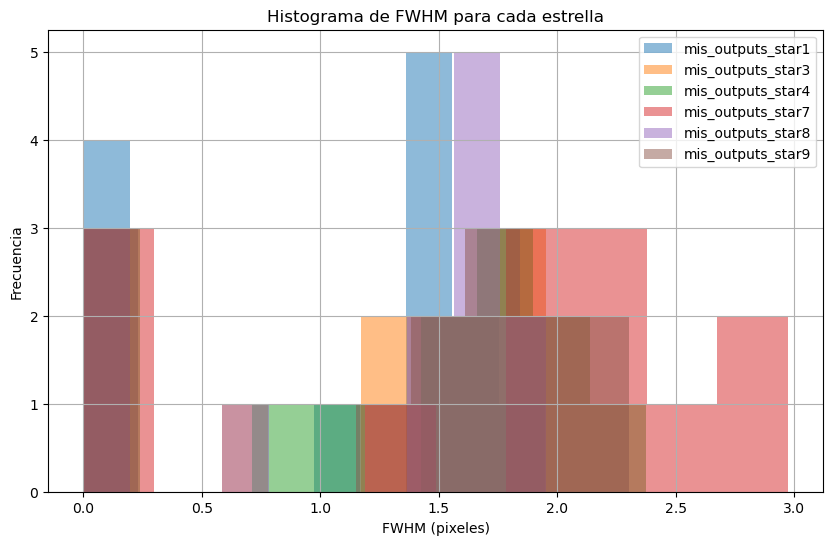

In [95]:
# hacer histograma de los fwhm
plt.figure(figsize=(10, 6))
for estrella in df_fwhm.columns:
    plt.hist(df_fwhm[estrella].dropna(), bins=10, alpha=0.5, label=estrella)
    # 
plt.xlabel('FWHM (pixeles)')
plt.ylabel('Frecuencia')
plt.title('Histograma de FWHM para cada estrella')
plt.legend()
plt.grid()
plt.show()

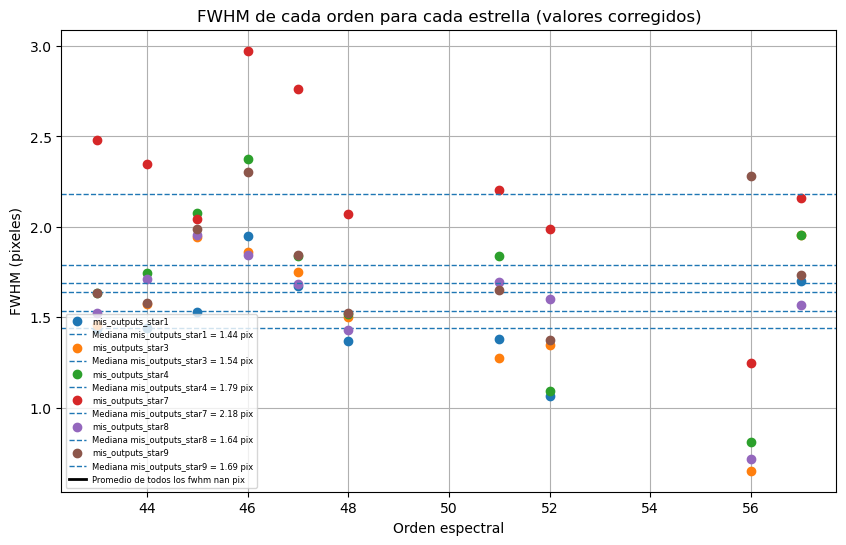

nan


In [ ]:
for estrella in df_fwhm.columns:
    
    valores = df_fwhm[estrella]
    
    # filtro físico (ajústalo si sabes mejor el rango esperado)
    valores_validos = valores[(valores > 0.5) & (valores < 2.5)]
    
    if len(valores_validos) == 0:
        continue
     # recortar outliers
    df_fwhm.loc[(df_fwhm[estrella] <= 0.5) | (df_fwhm[estrella] >= 3), estrella] = np.nan
    

todos_fwhms = []
plt.figure(figsize=(10, 6))
for estrella in df_fwhm.columns:
    todos_fwhms.extend(df_fwhm[estrella].values)
    plt.plot(df_fwhm[estrella], 'o', label=estrella)
     # hacer una línea horizontal con el valor de la mediana del fwhm para cada estrella
    plt.axhline(y=df_fwhm[estrella].median(), linestyle='--', linewidth=1, label=f'Mediana {estrella} = {df_fwhm[estrella].median():.2f} pix')
todos_fwhms = np.array(todos_fwhms)
promedio_fwhm = np.mean(todos_fwhms)
plt.axhline(y=promedio_fwhm, linestyle='-', linewidth=2, color='black', label=f'Promedio de todos los fwhm {promedio_fwhm:.2f} pix')
plt.xlabel('Orden espectral')
plt.gca().invert_xaxis()  # para que calcen bien los ordenes
plt.ylabel('FWHM (pixeles)')
plt.title('FWHM de cada orden para cada estrella (valores corregidos)')
plt.legend(loc = 'lower left', fontsize=6)
plt.grid()
plt.show()
print(promedio_fwhm)

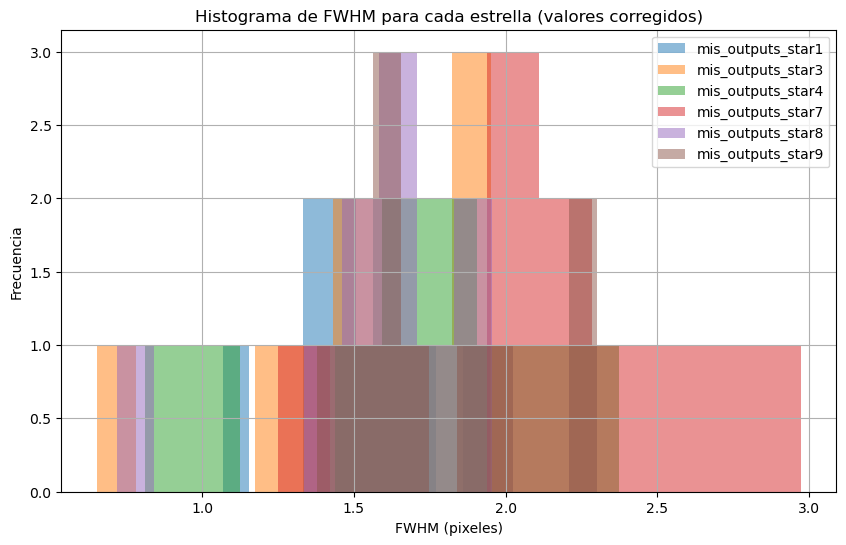

In [20]:
# histograma de los fwhm corregidos
plt.figure(figsize=(10, 6))
for estrella in df_fwhm.columns:
    plt.hist(df_fwhm[estrella].dropna(), bins=10, alpha=0.5, label=estrella)
plt.xlabel('FWHM (pixeles)')
plt.ylabel('Frecuencia')
plt.title('Histograma de FWHM para cada estrella (valores corregidos)')
plt.legend()
plt.grid()
plt.show()

/tmp/ipykernel_4039/3882967923.py:18: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_resolucion.iloc[i][estrella] = R
/tmp/ipykernel_4039/3882967923.py:20: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are

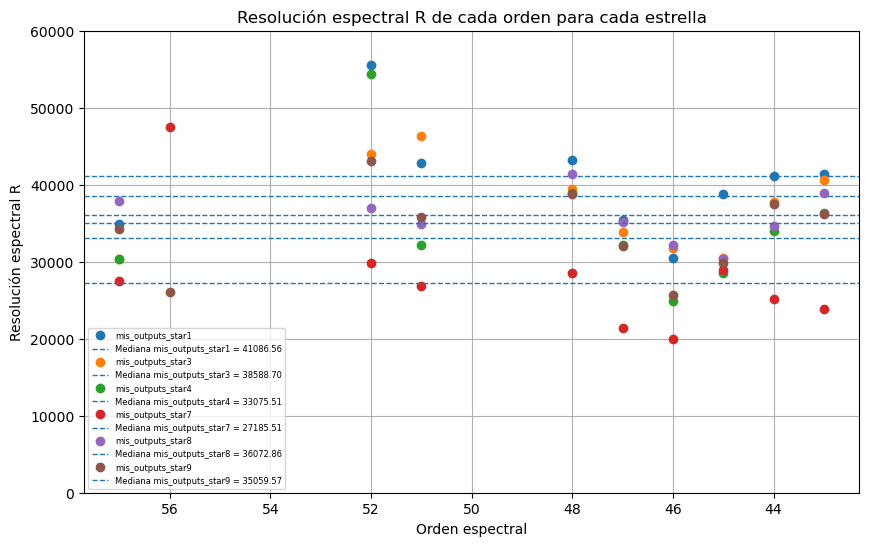

In [23]:
def resolucion_longitud_onda(crval1,cdelt1,fwhm_pix):
    
    # Calcular la resolución espectral R = λ / Δλ
    R = crval1/ (cdelt1 * fwhm_pix)
    
    return R

df_resolucion = pd.DataFrame(index=df_fwhm.index, columns=df_fwhm.columns)
df_resolucion = pd.DataFrame(index=df_fwhm.index, columns=df_fwhm.columns)

for estrella in df_fwhm.columns:
    for i in range(len(df_fwhm)):
        if i < len(df_calib[estrella]):
            crval1, cdelt1 = df_calib[estrella].iloc[i]  # <-- iloc
            fwhm_pix = df_fwhm[estrella].iloc[i]          # <-- iloc
            if pd.notna(fwhm_pix) and fwhm_pix > 0:
                R = resolucion_longitud_onda(crval1, cdelt1, fwhm_pix)
                df_resolucion.iloc[i][estrella] = R
            else:
                df_resolucion.iloc[i][estrella] = np.nan
        else:
            df_resolucion.iloc[i][estrella] = np.nan
#df_resolucion
plt.figure(figsize=(10, 6))
for estrella in df_resolucion.columns:
    plt.plot(df_resolucion[estrella], 'o', label=estrella)
    # hacer una línea horizontal con el valor de la mediana del fwhm para cada estrella
    plt.axhline(y=df_resolucion[estrella].median(), linestyle='--', linewidth=1, label=f'Mediana {estrella} = {df_resolucion[estrella].median():.2f}')
plt.xlabel('Orden espectral')
plt.gca().invert_xaxis()  # para que calcen bien los ordenes
plt.ylabel('Resolución espectral R')
plt.ylim(0, 60000)
plt.title('Resolución espectral R de cada orden para cada estrella')
plt.legend(loc = 'lower left', fontsize=6)
plt.grid()

In [91]:
from astropy.wcs import WCS
def extraer_craval_cdelt(archivo):
    with fits.open(archivo) as hdul:
        hdr = hdul[0].header
        data = hdul[0].data
        n_pix = data.shape[0]
        w = WCS(hdr, naxis=1)
        longitud_onda = w.pixel_to_world(np.arange(n_pix)).value
        central = longitud_onda[len(longitud_onda)//2]  # long onda central del orden
        cdelt1 = hdr.get('CDELT1', None)
        return central, cdelt1
# hacer df a mano
fwhm_estrella_4 = [4.38,4.16,3.98,3.83,3.69,3.58,3.33,3.30,3.28,3.28,3.25,3.24,3.25]
df_fwhm = pd.DataFrame(fwhm_estrella_4, columns=['mis_outputs_star4'])
# dataframe con los valore de crval1 y cdelt1 para cada orden de la estrella 4
paths = ["/home/nacho/molecfit_test/mis_outputs_star4"]
dic_2 = {}
for p in paths:
    archivos = glob.glob(os.path.join(p, '*modificado.fits'))
    nombre_estrella = os.path.basename(p)
    for archivo in archivos:
        craval1, cdelt1 = extraer_craval_cdelt(archivo)
        if craval1 is not None and cdelt1 is not None:
            
            if str(os.path.basename(nombre_estrella)) not in dic_2:
                dic_2[str(os.path.basename(nombre_estrella))] = []
            dic_2[str(os.path.basename(nombre_estrella))].append((craval1, cdelt1))
        else: 
            print(f"Archivo: {os.path.basename(archivo)} → No se encontraron CRVAL1 o CDELT1")
df_calib = pd.DataFrame.from_dict(dic_2, orient='index').transpose()
# calcular resolución espectral para cada orden de la estrella 4
df_resolucion = pd.DataFrame(index=df_fwhm.index, columns=df_fwhm.columns)
estrella = 'mis_outputs_star4'
for i in range(len(df_fwhm)):        
    if i < len(df_calib[estrella]):
        crval1, cdelt1 = df_calib[estrella][i]
        fwhm_pix = df_fwhm[estrella][i]
        if pd.notna(fwhm_pix) and fwhm_pix > 0:
            R = resolucion_longitud_onda(crval1, cdelt1, fwhm_pix)
            df_resolucion.at[i, estrella] = R
        else:
            df_resolucion.at[i, estrella] = np.nan
    else:
        df_resolucion.at[i, estrella] = np.nan
df_resolucion

a string value was expected. [astropy.wcs.wcs]


,mis_outputs_star4
0,13700.415021
1,14415.582072
2,15051.227686
3,15633.369666
4,16208.782274
5,16706.97572
6,17957.75467
7,18134.165545
8,18234.072709
9,18257.957039
